In [ ]:
# Lab 4

In [1]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

import utils
import platform
print("Torch loaded")

Torch loaded


In [2]:
def get_platform_device():
    '''

    Detects the OS and the best GPU to use on the device

    '''
    
    os_name = platform.system()
    processor = platform.processor()
    

    if torch.cuda.is_available():
        device = torch.device("cuda")
        platform_info = f"Nvidia GPU via CUDA ({os_name})"
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        platform_info = f"Apple Silicon via MPS ({os_name})"
    else:
        device = torch.device("cpu")
        platform_info = f"CPU fallback ({os_name} {processor})"
    
    print(f"Platform detected: {platform_info}")
    return device

device = get_platform_device()
print(f"Using device: {device}")

Platform detected: Apple Silicon via MPS (Darwin)
Using device: mps


In [3]:
FILEPATH = "data/asl_data/sign_mnist_train.csv"



IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1
N_CLASSES = 24

train_df = pd.read_csv(FILEPATH)
valid_df = pd.read_csv(FILEPATH)

class MyDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255  # Normalize values from 0 to 1
        x_df = x_df.reshape(-1, IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

n = 32
train_data = MyDataset(train_df)
train_loader = DataLoader(train_data, batch_size=n, shuffle=True)
train_N = len(train_loader.dataset)

valid_data = MyDataset(valid_df)
valid_loader = DataLoader(valid_data, batch_size=n)
valid_N = len(valid_loader.dataset)
print("Complete")

Complete


In [4]:
class MyConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        kernel_size = 3
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [5]:
flattened_img_size = 75 * 3 * 3

# Input 1 x 28 x 28
base_model = nn.Sequential(
    MyConvBlock(IMG_CHS, 25, 0), # 25 x 14 x 14
    MyConvBlock(25, 50, 0.2), # 50 x 7 x 7
    MyConvBlock(50, 75, 0),  # 75 x 3 x 3
    # Flatten to Dense Layers
    nn.Flatten(),
    nn.Linear(flattened_img_size, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, N_CLASSES)
)
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(base_model.parameters())

backend = "aot_eager" if device.type == "mps" else "inductor"   # Inductor breaks sometimes
model = torch.compile(base_model.to(device), backend=backend)
model

OptimizedModule(
  (_orig_mod): Sequential(
    (0): MyConvBlock(
      (model): Sequential(
        (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0, inplace=False)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): MyConvBlock(
      (model): Sequential(
        (0): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): MyConvBlock(
      (model): Sequential(
        (0): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(75, eps=1e-05, momentum=0.1, affin

In [6]:
row_0 = train_df.head(1)
y_0 = row_0.pop('label')
x_0 = row_0.values / 255
x_0 = x_0.reshape(IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
x_0 = torch.tensor(x_0)
x_0.shape

torch.Size([1, 28, 28])

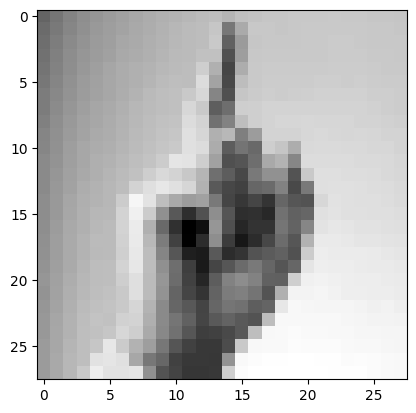

In [7]:
image = F.to_pil_image(x_0)
plt.imshow(image, cmap='gray')

In [8]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

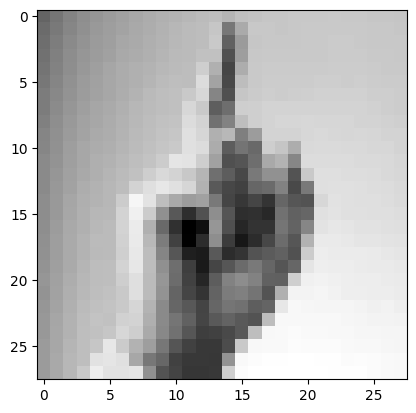

In [9]:
new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

In [10]:
new_x_0.shape

torch.Size([1, 28, 28])

In [11]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

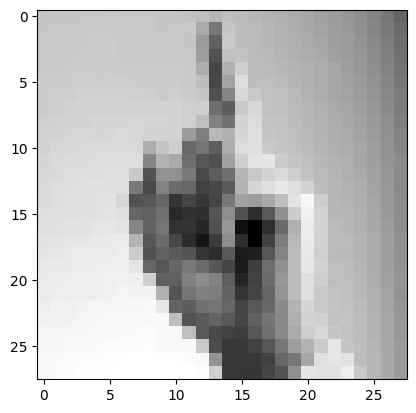

In [12]:
new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

In [13]:
trans = transforms.Compose([
    transforms.RandomRotation(10)
])

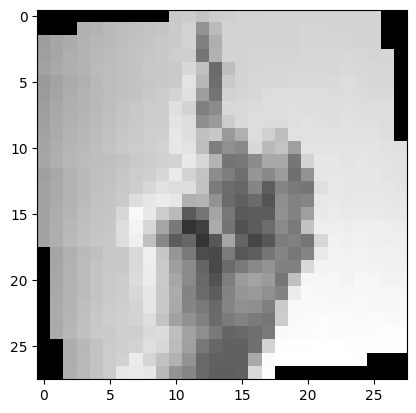

In [14]:
new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

In [15]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

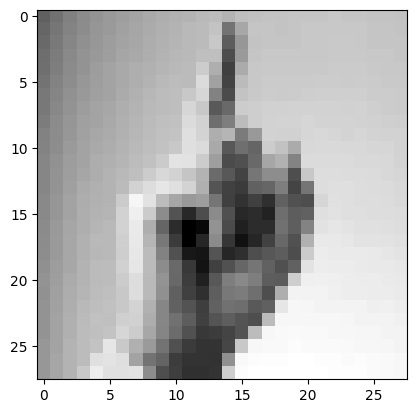

In [16]:
new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

In [17]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

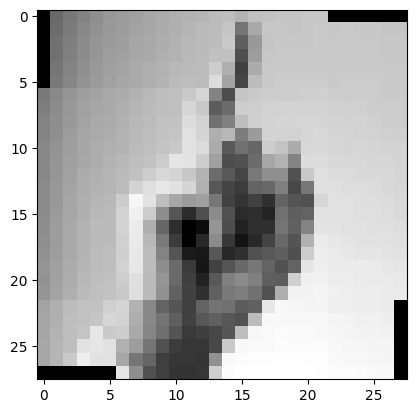

In [18]:
new_x_0 = random_transforms(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

In [19]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(random_transforms(x))  # Updated
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += utils.get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [20]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += utils.get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [21]:
epochs = 20

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch+1))
    train()
    validate()
print("Training Complete")

Epoch: 1


/Users/billy/Code/Python/Lab/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Error detected in MaxPool2DBackward0. Traceback of forward call that caused the error:
  File "/var/folders/y2/4kd1tmp10m717nhvcc4xcl680000gn/T/ipykernel_16277/250187466.py", line 15, in forward
    return self.model(x)
 (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_anomaly_mode.cpp:127.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
W0428 12:51:55.179000 16277 torch/_dynamo/exc.py:623] [0/1] Backend compiler exception
W0428 12:51:55.179000 16277 torch/_dynamo/exc.py:623] [0/1]   Explanation: Backend compiler `aot_eager` failed with aten.max_pool2d_backward.default. Adding a graph break.
W0428 12:51:55.179000 16277 torch/_dynamo/exc.py:623] [0/1]   Hint: Report an issue to the backend compiler repo.
W0428 12:51:55.179000 16277 torch/_dynamo/exc.py:623] [0/1] 
W0428 12:51:55.17

Train - Loss: 668.1735 Accuracy: 0.7466
Valid - Loss: 99.6869 Accuracy: 0.9673
Epoch: 2
Train - Loss: 103.4446 Accuracy: 0.9606
Valid - Loss: 13.4604 Accuracy: 0.9980
Epoch: 3
Train - Loss: 61.3403 Accuracy: 0.9770
Valid - Loss: 25.7927 Accuracy: 0.9917
Epoch: 4
Train - Loss: 41.2558 Accuracy: 0.9842
Valid - Loss: 1.9283 Accuracy: 0.9999
Epoch: 5
Train - Loss: 33.0850 Accuracy: 0.9880
Valid - Loss: 5.0715 Accuracy: 0.9989
Epoch: 6
Train - Loss: 31.3834 Accuracy: 0.9887
Valid - Loss: 21.0447 Accuracy: 0.9918
Epoch: 7
Train - Loss: 25.2998 Accuracy: 0.9904
Valid - Loss: 2.5707 Accuracy: 0.9990
Epoch: 8
Train - Loss: 26.2635 Accuracy: 0.9898
Valid - Loss: 56.0230 Accuracy: 0.9794
Epoch: 9
Train - Loss: 18.2427 Accuracy: 0.9934
Valid - Loss: 0.7498 Accuracy: 1.0000
Epoch: 10
Train - Loss: 16.0481 Accuracy: 0.9942
Valid - Loss: 3.7836 Accuracy: 0.9981
Epoch: 11
Train - Loss: 18.3697 Accuracy: 0.9935
Valid - Loss: 0.2446 Accuracy: 1.0000
Epoch: 12
Train - Loss: 14.9293 Accuracy: 0.9938
Valid

In [22]:
torch.save(base_model, 'model.pth')

In [23]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}